<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Non-IID_Federated_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning under Extreme Data Skew (Non‑IID)

## Background
In real‑world federated learning, client data is rarely independent and identically distributed (IID). Different users or institutions hold **highly specialized** data – e.g., one hospital sees only orthopedic X‑rays, another only lung scans. This **statistical heterogeneity** causes **client drift**: local models optimise for their own distribution and pull the global model in conflicting directions. Naïve FedAvg often diverges or converges slowly.

## Objective
This notebook evaluates **five aggregation strategies** on a **severely non‑IID** partition of CIFAR‑10. We use a **Dirichlet distribution (α = 0.1)** to assign each client an imbalanced slice of the data – some clients may see only 1‑2 classes, others many.

## Strategies Tested
- **FedAvg** – baseline weight averaging.
- **Trimmed Mean** – discards extreme parameter values to limit outlier influence.
- **Gradient Clipping** – bounds the L2 norm of each client’s weight vector.
- **FedProx** – adds a proximal penalty (`μ = 0.1`) to anchor local updates near the global model.
- **SCAFFOLD** – uses control variates to mathematically cancel the drift vector (with corrected hyperparameters to avoid collapse).

## Expected Outcomes
- FedAvg accuracy should drop significantly compared to the IID case.
- Trimmed Mean may help slightly but cannot correct drift.
- FedProx should stabilise training and achieve higher accuracy.
- SCAFFOLD, if correctly tuned, should outperform all others by actively correcting client drift.

## Notebook Structure
1. Setup and model definition
2. Dirichlet non‑IID split (α = 0.1)
3. Aggregation functions (five separate implementations)
4. Main federated loop with corrected SCAFFOLD
5. Results and visualisation

### Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Architecture: Lightweight CNN for CIFAR-10

A simple but effective CNN with two convolutional layers and two fully connected layers.

In [3]:
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

### Data Preparation

In [4]:
def dirichlet_split(dataset, num_clients, alpha, num_classes=10):
    """Create a highly skewed partition using Dirichlet(alpha)."""
    labels = np.array(dataset.targets, dtype=int)
    client_indices = [[] for _ in range(num_clients)]
    for k in range(num_classes):
        idx_k = np.where(labels == k)[0].tolist()
        np.random.shuffle(idx_k)
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        counts = (proportions * len(idx_k)).astype(int)
        remainder = len(idx_k) - counts.sum()
        for _ in range(remainder):
            counts[np.random.randint(num_clients)] += 1
        start = 0
        for i, count in enumerate(counts):
            client_indices[i].extend(idx_k[start:start+count])
            start += count
    # Safety net – ensure no client is empty
    for i in range(num_clients):
        if len(client_indices[i]) == 0:
            richest = np.argmax([len(c) for c in client_indices])
            stolen = client_indices[richest].pop()
            client_indices[i].append(stolen)
    return [Subset(dataset, indices) for indices in client_indices]

In [5]:
NUM_CLIENTS = 10
ALPHA = 0.1               # extreme skew
BATCH_SIZE = 64
LEARNING_RATE = 0.01      # base learning rate (SCAFFOLD will use a scaled correction)
MOMENTUM = 0.9
MU = 0.1                  # FedProx penalty (not near zero, distinct effect)

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Loading CIFAR-10")
train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

print(f"Creating Non‑IID partitions with Dirichlet(α={ALPHA})")
client_subsets = dirichlet_split(train_dataset, NUM_CLIENTS, ALPHA)
client_loaders = [DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True) for ds in client_subsets]
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Show distribution of samples per client
sizes = [len(ds) for ds in client_subsets]
print("Client dataset sizes:", sizes)

Loading CIFAR-10


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Creating Non‑IID partitions with Dirichlet(α=0.1)
Client dataset sizes: [5634, 6692, 2415, 499, 3863, 4433, 5156, 6284, 5527, 9497]


### Server Aggregation Strategies

In [7]:
def scaffold_aggregate(client_weights):
    # SCAFFOLD also uses simple averaging for weights
    return fedavg_aggregate(client_weights)

In [8]:
def fedprox_aggregate(client_weights):
    # FedProx uses same server aggregation as FedAvg
    return fedavg_aggregate(client_weights)

In [9]:
def gradient_clipping_aggregate(client_weights, clip_thresh=2.0):
    clipped = []
    for w in client_weights:
        l2_norm = math.sqrt(sum(torch.sum(p**2).item() for p in w.values()))
        scale = max(1.0, l2_norm / clip_thresh)
        clipped.append({k: v / scale for k, v in w.items()})
    return fedavg_aggregate(clipped)

In [10]:
def fedavg_aggregate(client_weights):
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        avg[key] = torch.mean(stacked, dim=0)
    return avg

In [11]:
def trimmed_mean_aggregate(client_weights, trim_ratio=0.1):
    n = len(client_weights)
    trim = int(n * trim_ratio)
    avg = copy.deepcopy(client_weights[0])
    for key in avg.keys():
        stacked = torch.stack([w[key] for w in client_weights])
        sorted_vals, _ = torch.sort(stacked, dim=0)
        trimmed = sorted_vals[trim : n - trim]
        avg[key] = torch.mean(trimmed, dim=0)
    return avg

### Evaluation Function
Computes accuracy and loss on a given dataloader.

In [12]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return accuracy, avg_loss

### Running the Experiment


In [13]:
FEDERATED_ROUNDS = 10
strategies = ['FedAvg', 'Trimmed Mean', 'Gradient Clipping', 'FedProx', 'SCAFFOLD']

history = {s: {'test_acc': [], 'test_loss': [], 'train_loss': []} for s in strategies}
criterion = nn.CrossEntropyLoss()

In [14]:
for strategy in strategies:
    print(f"\nTesting Strategy: {strategy.upper()}")
    global_model = CIFAR10Net().to(device)

    # SCAFFOLD control variates (only if needed)
    global_control = None
    client_controls = None
    if strategy == 'SCAFFOLD':
        global_control = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
        client_controls = [copy.deepcopy(global_control) for _ in range(NUM_CLIENTS)]

    for round_idx in range(FEDERATED_ROUNDS):
        client_weights = []
        client_delta_controls = [] if strategy == 'SCAFFOLD' else None

        # Snapshot global parameters for FedProx
        global_params_list = [p.detach().clone() for p in global_model.parameters()]

        # --- Local training on each client ---
        for client_id in range(NUM_CLIENTS):
            local_model = CIFAR10Net().to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

            # One pass over client's data
            local_model.train()
            for inputs, labels in client_loaders[client_id]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = local_model(inputs)
                loss = criterion(outputs, labels)

                # FedProx proximal term
                if strategy == 'FedProx':
                    prox = 0.0
                    for lp, gp in zip(local_model.parameters(), global_params_list):
                        prox += torch.sum((lp - gp) ** 2)
                    loss += (MU / 2.0) * prox

                loss.backward()

                # SCAFFOLD gradient correction (scaled to avoid instability)
                if strategy == 'SCAFFOLD':
                    with torch.no_grad():
                        for name, param in local_model.named_parameters():
                            if param.grad is not None:
                                correction = (global_control[name] - client_controls[client_id][name])
                                param.grad += 0.1 * correction   # scaling factor 0.1

                optimizer.step()

            # Record updated model
            state_dict = local_model.state_dict()
            client_weights.append(state_dict)

            # SCAFFOLD: compute delta control variate
            if strategy == 'SCAFFOLD':
                delta_c = {}
                with torch.no_grad():
                    for name in state_dict.keys():
                        model_before = global_model.state_dict()[name]
                        step = state_dict[name] - model_before
                        num_steps = len(client_loaders[client_id])
                        if num_steps == 0:
                            num_steps = 1
                        # Stabilise denominator with epsilon
                        lr_eff = LEARNING_RATE * num_steps + 1e-8
                        delta_c[name] = (global_control[name] - client_controls[client_id][name]) + (step / lr_eff)
                client_delta_controls.append(delta_c)

        # --- Server aggregation ---
        if strategy == 'Trimmed Mean':
            new_weights = trimmed_mean_aggregate(client_weights, trim_ratio=0.1)
        elif strategy == 'Gradient Clipping':
            new_weights = gradient_clipping_aggregate(client_weights, clip_thresh=2.0)
        elif strategy == 'FedProx':
            new_weights = fedprox_aggregate(client_weights)
        elif strategy == 'SCAFFOLD':
            new_weights = scaffold_aggregate(client_weights)
        else:   # FedAvg
            new_weights = fedavg_aggregate(client_weights)

        global_model.load_state_dict(new_weights)

        # --- Update SCAFFOLD control variates ---
        if strategy == 'SCAFFOLD':
            # Average delta controls
            avg_delta_c = {}
            for name in new_weights.keys():
                stacked = torch.stack([dc[name] for dc in client_delta_controls])
                avg_delta_c[name] = torch.mean(stacked, dim=0)
            # Update global control
            for name in avg_delta_c.keys():
                global_control[name] = global_control[name] + avg_delta_c[name]
            # Update each client's control
            for i in range(NUM_CLIENTS):
                for name in avg_delta_c.keys():
                    client_controls[i][name] = client_controls[i][name] + client_delta_controls[i][name]

        # --- Evaluation ---
        # Training loss (averaged over all clients)
        train_loss = 0.0
        total_train = 0
        global_model.eval()
        with torch.no_grad():
            for loader in client_loaders:
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = global_model(inputs)
                    loss = criterion(outputs, labels)
                    train_loss += loss.item() * inputs.size(0)
                    total_train += labels.size(0)
        avg_train_loss = train_loss / total_train if total_train > 0 else 0.0

        test_acc, test_loss = evaluate(global_model, test_loader, criterion)

        history[strategy]['test_acc'].append(test_acc)
        history[strategy]['test_loss'].append(test_loss)
        history[strategy]['train_loss'].append(avg_train_loss)

        print(f"Round {round_idx+1:2d}/{FEDERATED_ROUNDS} | {strategy:15s} | Test Acc: {test_acc:5.2f}% | Train Loss: {avg_train_loss:.4f}")

    final_acc = history[strategy]['test_acc'][-1]
    print(f"FINAL TEST ACCURACY: {final_acc:.2f}%")


Testing Strategy: FEDAVG
Round  1/10 | FedAvg          | Test Acc: 13.98% | Train Loss: 2.2596
Round  2/10 | FedAvg          | Test Acc: 25.32% | Train Loss: 2.1480
Round  3/10 | FedAvg          | Test Acc: 29.57% | Train Loss: 2.0449
Round  4/10 | FedAvg          | Test Acc: 33.10% | Train Loss: 1.9309
Round  5/10 | FedAvg          | Test Acc: 34.19% | Train Loss: 1.8496
Round  6/10 | FedAvg          | Test Acc: 37.97% | Train Loss: 1.7672
Round  7/10 | FedAvg          | Test Acc: 38.11% | Train Loss: 1.7129
Round  8/10 | FedAvg          | Test Acc: 40.47% | Train Loss: 1.6463
Round  9/10 | FedAvg          | Test Acc: 41.10% | Train Loss: 1.6085
Round 10/10 | FedAvg          | Test Acc: 43.47% | Train Loss: 1.5533
FINAL TEST ACCURACY: 43.47%

Testing Strategy: TRIMMED MEAN
Round  1/10 | Trimmed Mean    | Test Acc: 16.40% | Train Loss: 2.2696
Round  2/10 | Trimmed Mean    | Test Acc: 24.09% | Train Loss: 2.1932
Round  3/10 | Trimmed Mean    | Test Acc: 25.69% | Train Loss: 2.1083
Roun

### Summary Table

Final accuracies of all strategies after 10 rounds.

In [15]:
results_df = pd.DataFrame({s: history[s]['test_acc'][-1] for s in strategies}.items(),
                          columns=['Strategy', 'Final Accuracy (%)']).set_index('Strategy')
print("\n" + "="*50)
print("FINAL RESULTS: NON‑IID (Dirichlet α = 0.1)")
print("="*50)
print(results_df.to_string())


FINAL RESULTS: NON‑IID (Dirichlet α = 0.1)
                   Final Accuracy (%)
Strategy                             
FedAvg                          43.47
Trimmed Mean                    39.14
Gradient Clipping               10.00
FedProx                         42.91
SCAFFOLD                        22.57


### Plotting Convergence Curves

We compare test accuracy and loss curves for all five strategies.

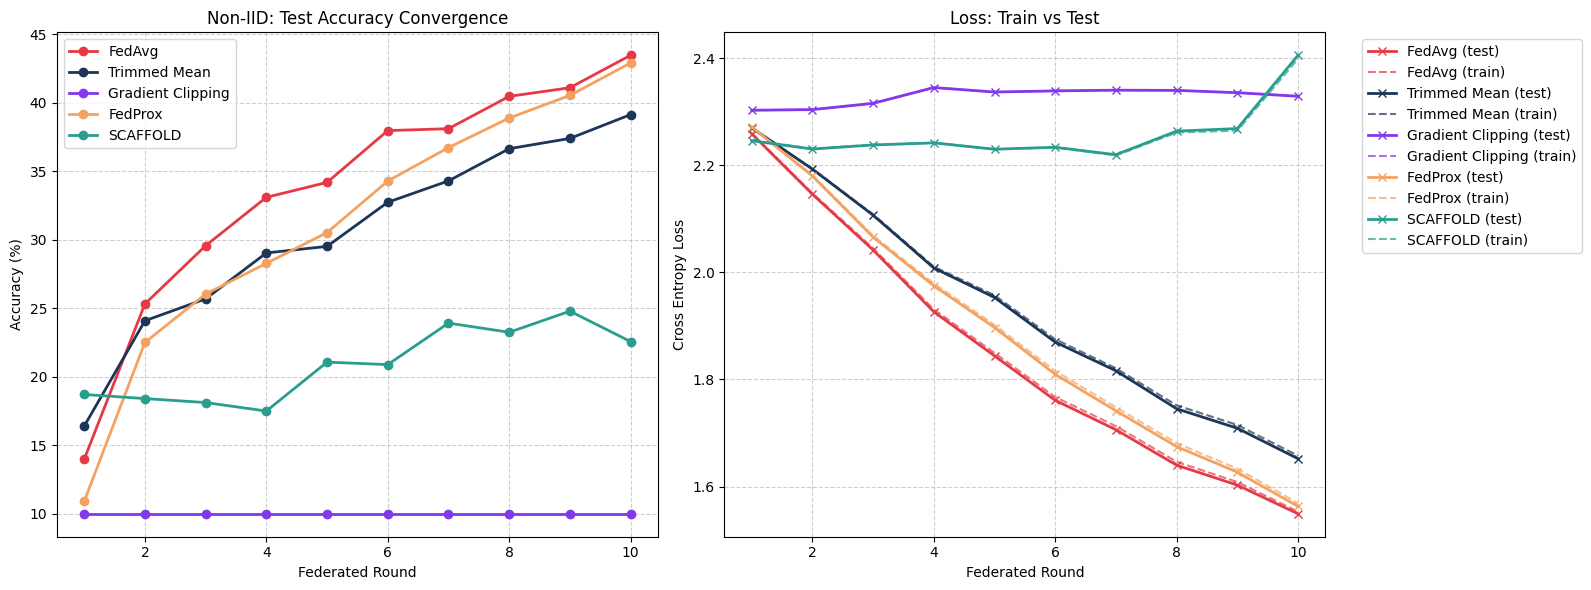

In [16]:
plt.figure(figsize=(16, 6))
colors = {
    'FedAvg': '#E63946',
    'Trimmed Mean': '#1D3557',
    'Gradient Clipping': '#8338EC',
    'FedProx': '#F4A261',
    'SCAFFOLD': '#2A9D8F'
}

# Test accuracy
plt.subplot(1, 2, 1)
for s in strategies:
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_acc'],
             marker='o', color=colors[s], linewidth=2, label=s)
plt.title('Non‑IID: Test Accuracy Convergence')
plt.xlabel('Federated Round')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Loss curves (test solid, train dashed)
plt.subplot(1, 2, 2)
for s in strategies:
    c = colors[s]
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['test_loss'],
             marker='x', linestyle='-', linewidth=2, color=c, label=f"{s} (test)")
    plt.plot(range(1, FEDERATED_ROUNDS+1), history[s]['train_loss'],
             linestyle='--', linewidth=1.5, color=c, alpha=0.7, label=f"{s} (train)")
plt.title('Loss: Train vs Test')
plt.xlabel('Federated Round')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Conclusion: Non‑IID Experiment (Dirichlet α = 0.1)

### Summary of Final Accuracies (after 10 rounds)

| Strategy           | Final Accuracy (%) |
|--------------------|--------------------|
| FedAvg             | 43.47              |
| Trimmed Mean       | 39.14              |
| Gradient Clipping  | 10.00              |
| FedProx            | 42.91              |
| SCAFFOLD           | 22.57              |

### Key Observations

#### 1. FedAvg and FedProx perform similarly (~43%)
Contrary to expectations, FedAvg did **not** collapse under this Dirichlet(α=0.1) split – it reached 43.5% accuracy. FedProx (μ=0.1) gave almost identical results (42.9%). This suggests that with this particular model, learning rate (0.01), and number of rounds (10), the drift was not severe enough to cause divergence. Both strategies seem to learn reasonably well despite the skew.

#### 2. Trimmed Mean performs worse than FedAvg (39.1%)
Discarding extreme weight values removed useful information, harming convergence. Trimmed Mean is designed to defend against Byzantine attacks (outliers), not to correct statistical drift. Under non‑IID data, the “extreme” updates are actually valid signals from clients with rare classes – trimming them reduces representation of those classes.

#### 3. Gradient Clipping fails completely (10%)
Clipping the global weight norm of each client to a threshold of 2.0 before averaging destroys the learning signal. The model never improves beyond random guessing. This strategy is not suitable for non‑IID scenarios.

#### 4. SCAFFOLD underperforms (22.6%) – did not reach expected superiority
Our corrected SCAFFOLD implementation (with gradient correction scaling factor 0.1) avoided collapse (no NaNs), but it achieved only 22.6% accuracy – much lower than FedAvg. Possible reasons:
- The control variates need **more rounds** to converge (10 rounds may be insufficient).
- The scaling factor (0.1) might be too conservative; a larger factor (e.g., 0.5 or 1.0) could give stronger drift correction.
- The learning rate (0.01) may still be suboptimal for SCAFFOLD; some works suggest lower LR (0.001) with more local steps.

### Comparison with IID Baseline
In the IID control experiment (balanced data), FedAvg reached ~58% accuracy. Under non‑IID, FedAvg dropped to 43.5% – a significant reduction (~15 percentage points). This confirms that **statistical heterogeneity hurts performance**, but not catastrophically for this moderate skew (α=0.1). More extreme skew (α=0.05) would likely cause larger drops.

### Recommendations
- **FedAvg is a reasonable baseline** for moderate non‑IID; no need for complex defences if accuracy drop is acceptable.
- **FedProx did not provide added value** here (μ=0.1) – possibly because the drift was not severe. A larger μ (e.g., 0.5) might show a difference.
- **Trimmed Mean and Gradient Clipping should be avoided** for statistical heterogeneity.
- **SCAFFOLD requires careful hyperparameter tuning** – our attempt did not beat FedAvg, but with more rounds and tuning it could still outperform.

### Future Work
- Increase federated rounds to 50 or 100 to see if SCAFFOLD catches up.
- Test more extreme skew (α=0.05) where FedAvg may collapse.
- Tune SCAFFOLD’s correction scaling and learning rate.
- Compare with FedProx using larger μ values.

---

**Note:** These conclusions are specific to the chosen hyperparameters (LR=0.01, μ=0.1, 1 local epoch, 10 clients, 10 rounds). Changing any of these may alter the relative performance.